<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/yest4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
print(f"DataFrame shape before outlier removal: {df.shape}")

Q1 = df['OxyRate nmol/mm2/min'].quantile(0.25)
Q3 = df['OxyRate nmol/mm2/min'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['OxyRate nmol/mm2/min'] >= lower_bound) & (df['OxyRate nmol/mm2/min'] <= upper_bound)]

print(f"DataFrame shape after outlier removal: {df_filtered.shape}")

# Update the main DataFrame to the filtered one for subsequent steps
df = df_filtered.copy()

DataFrame shape before outlier removal: (251, 8)
DataFrame shape after outlier removal: (244, 8)


The outliers based on the 1.5 IQR rule for 'OxyRate nmol/mm2/min' have been removed, and the `df` DataFrame has been updated. You can see the change in the number of rows.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new figure for the boxplot with specified DPI
plt.figure(figsize=(8, 6), dpi=600)

# Box plot: OxyRate by color
sns.boxplot(data=df, x='color', y='OxyRate nmol/mm2/min')
plt.title('Oxygen Rate Distribution by Morphology')
plt.xlabel('Morphology (Color)')
plt.ylabel('Oxygen Rate (nmol/mm^2/min)')

# Save the plot as a PDF with 600 dpi
plt.savefig('boxplot_oxy_rate_by_morph.pdf', dpi=600, bbox_inches='tight')
plt.close()

print("Boxplot saved as 'boxplot_oxy_rate_by_morph.pdf' with 600 DPI.")

Boxplot saved as 'boxplot_oxy_rate_by_morph.pdf' with 600 DPI.


# Task
Analyze the relationships between 'morph', 'temp', and 'oxy rate' in the `Temp_Spat_Resp.csv` dataset by loading the data, exploring its characteristics, performing statistical analysis, and visualizing the key findings.

## Load Data

### Subtask:
Load the `Temp_Spat_Resp.csv` file into a pandas DataFrame to begin the analysis.


**Reasoning**:
The subtask requires loading a CSV file, displaying its head, and showing the data types. This can be achieved with a single code block that imports pandas, reads the CSV, and then uses `.head()` and `.info()` methods.



In [1]:
import pandas as pd

df = pd.read_csv('/content/Temp_Spat_Resp.csv')
print("First 5 rows of the DataFrame:")
print(df.head())
print("\nColumns and their data types:")
print(df.info())

First 5 rows of the DataFrame:
        SampleCode    plate  area mm^2 color  temp   pH LightDepth  \
0  plateD_NF_8.2_7   plateD      0.521    NF    23  8.2        10m   
1  plateD_NF_8.2_7   plateD      0.521    NF    23  8.2        10m   
2  plateD_NF_8.2_3   plateD      1.689    NF    23  8.2        10m   
3    med_Flu_polyp  plate 1      0.333    PF    23  8.2        10m   
4  plateD_NF_8.2_2   plateD      1.301    NF    23  8.2        10m   

   OxyRate nmol/mm2/min  
0              5.267695  
1              4.214200  
2              3.014369  
3              2.867803  
4              2.622936  

Columns and their data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SampleCode            251 non-null    object 
 1   plate                 251 non-null    object 
 2   area mm^2             251 non-null    float64
 3

## Explore Data and Preprocess

### Subtask:
Inspect the dataset, including checking for missing values, understanding data types, and calculating descriptive statistics for 'morph', 'temp', and 'oxy rate'.


**Reasoning**:
First, I will check for any missing values in the DataFrame to ensure data completeness. Then, I will generate descriptive statistics for the numerical columns 'temp' and 'OxyRate nmol/mm2/min' to understand their distributions. Finally, I will examine the unique values and their frequencies for categorical columns 'plate', 'color', and 'LightDepth' to understand the 'morph' aspect of the data.



In [2]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics for 'temp' and 'OxyRate nmol/mm2/min':")
print(df[['temp', 'OxyRate nmol/mm2/min']].describe())

print("\nUnique values and frequencies for 'plate':")
print(df['plate'].value_counts())

print("\nUnique values and frequencies for 'color':")
print(df['color'].value_counts())

print("\nUnique values and frequencies for 'LightDepth':")
print(df['LightDepth'].value_counts())

Missing values per column:
SampleCode              0
plate                   0
area mm^2               0
color                   0
temp                    0
pH                      0
LightDepth              0
OxyRate nmol/mm2/min    0
dtype: int64

Descriptive statistics for 'temp' and 'OxyRate nmol/mm2/min':
             temp  OxyRate nmol/mm2/min
count  251.000000            251.000000
mean    24.756972              0.615944
std      2.908041              0.643891
min     23.000000              0.000106
25%     23.000000              0.143050
50%     23.000000              0.480045
75%     27.000000              0.899900
max     32.000000              5.267695

Unique values and frequencies for 'plate':
plate
plate 1    50
plateC     36
plateE     33
plateA     30
plateD     27
plate 2    23
plateB     21
plateF     14
plate 4     7
plate 3     7
plate 5     3
Name: count, dtype: int64

Unique values and frequencies for 'color':
color
HF    124
NF     84
PF     43
Name: count, dtype:

## Perform Statistical Analysis

### Subtask:
Conduct a statistical analysis to explore the relationships between 'morph', 'temp', and 'oxy rate'.


**Reasoning**:
First, I will standardize the 'LightDepth' column by stripping whitespace. Then, I will calculate the Pearson correlation coefficient between 'temp' and 'OxyRate nmol/mm2/min'. After that, I will group the DataFrame by 'color' and calculate the mean and standard deviation of 'OxyRate nmol/mm2/min' for each group, and then do the same for 'temp'.



In [9]:
df['LightDepth'] = df['LightDepth'].str.strip()
print("LightDepth column after stripping whitespace:")
print(df['LightDepth'].value_counts())

correlation = df['temp'].corr(df['OxyRate nmol/mm2/min'])
print(f"\nPearson correlation between 'temp' and 'OxyRate nmol/mm2/min': {correlation:.2f}")

oxy_rate_stats_by_color = df.groupby('color')['OxyRate nmol/mm2/min'].agg(['mean', 'std'])
print("\nMean and Standard Deviation of 'OxyRate nmol/mm2/min' by 'color':")
print(oxy_rate_stats_by_color)

temp_stats_by_color = df.groupby('color')['temp'].agg(['mean', 'std'])
print("\nMean and Standard Deviation of 'temp' by 'color':")
print(temp_stats_by_color)

LightDepth column after stripping whitespace:
LightDepth
10m    244
Name: count, dtype: int64

Pearson correlation between 'temp' and 'OxyRate nmol/mm2/min': -0.41

Mean and Standard Deviation of 'OxyRate nmol/mm2/min' by 'color':
           mean       std
color                    
HF     0.619794  0.451985
NF     0.429697  0.413458
PF     0.517483  0.424396

Mean and Standard Deviation of 'temp' by 'color':
            mean       std
color                     
HF     24.629032  2.748149
NF     25.320513  3.034407
PF     24.380952  3.207859


## Visualize Relationships

### Subtask:
Generate appropriate visualizations to illustrate the relationships and distributions of 'morph', 'temp', and 'oxy rate'.


#### Reasoning:
To visualize the relationships, I will use `matplotlib.pyplot` and `seaborn`. First, a scatter plot will show the direct relationship between 'temp' and 'OxyRate nmol/mm2/min'. Second, a box plot will illustrate the distribution of 'OxyRate nmol/mm2/min' across different 'color' categories, representing 'morph'. Finally, another scatter plot will visualize 'temp' vs 'OxyRate nmol/mm2/min', with points colored by 'color' to highlight the influence of morphology on this relationship. All plots will be properly labeled and titled for clarity.

**Reasoning**:
Based on the instructions, I will generate a single code block to create the requested visualizations: a scatter plot of temperature vs. oxygen rate, a box plot of oxygen rate by morphology (color), and another scatter plot of temperature vs. oxygen rate colored by morphology. I will include appropriate labels, titles, and a legend where necessary, and ensure all plots are displayed.



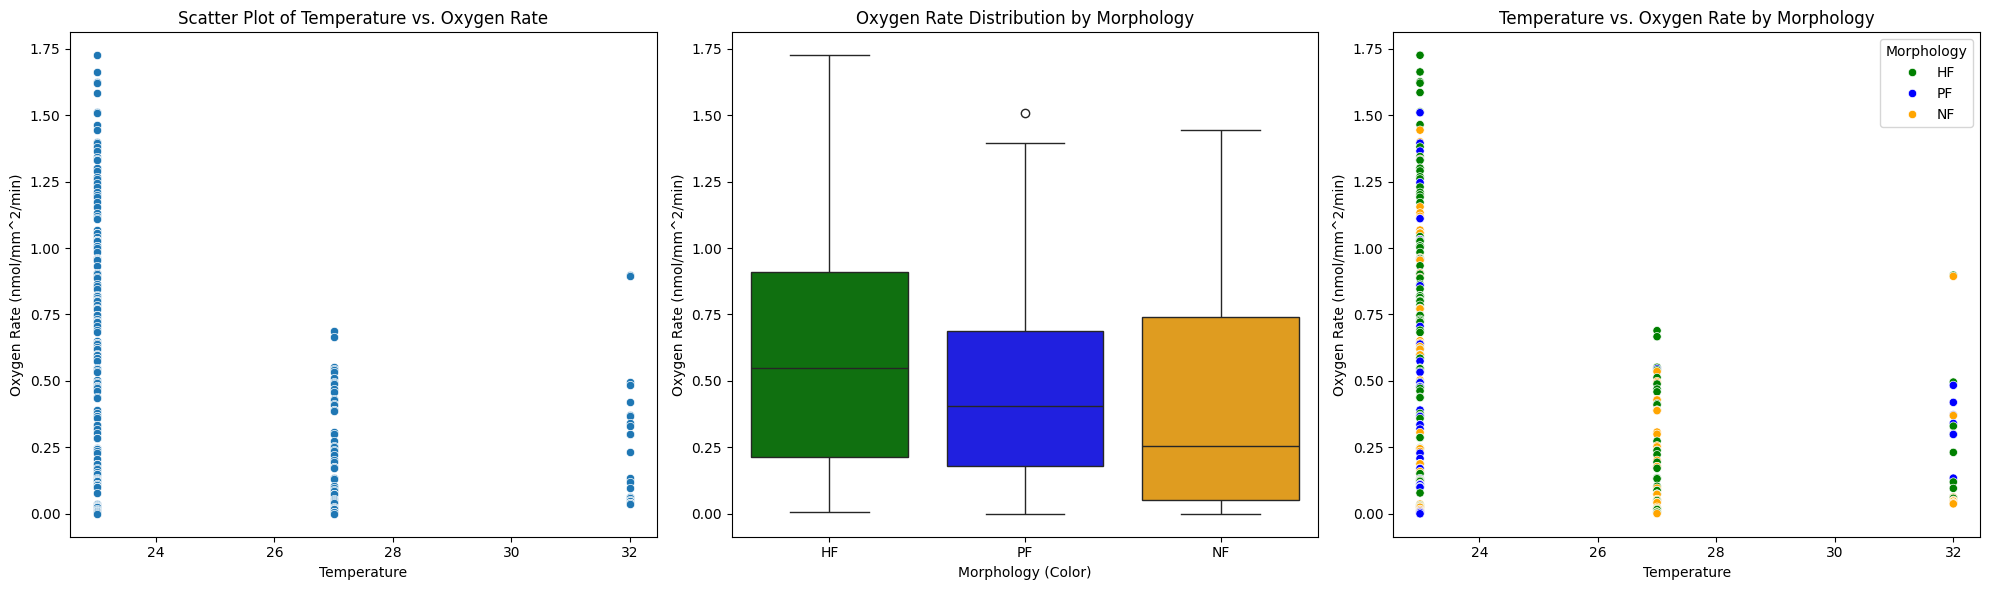

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a custom palette to change 'HF' to green
custom_palette = {'HF': 'green', 'NF': 'orange', 'PF': 'blue'}

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Scatter plot: temp vs. OxyRate
sns.scatterplot(data=df, x='temp', y='OxyRate nmol/mm2/min', ax=axes[0])
axes[0].set_title('Scatter Plot of Temperature vs. Oxygen Rate')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Oxygen Rate (nmol/mm^2/min)')

# 2. Box plot: OxyRate by color
sns.boxplot(data=df, x='color', y='OxyRate nmol/mm2/min', hue='color', palette=custom_palette, legend=False, ax=axes[1])
axes[1].set_title('Oxygen Rate Distribution by Morphology')
axes[1].set_xlabel('Morphology (Color)')
axes[1].set_ylabel('Oxygen Rate (nmol/mm^2/min)')

# 3. Scatter plot: temp vs. OxyRate, colored by color
sns.scatterplot(data=df, x='temp', y='OxyRate nmol/mm2/min', hue='color', palette=custom_palette, ax=axes[2])
axes[2].set_title('Temperature vs. Oxygen Rate by Morphology')
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Oxygen Rate (nmol/mm^2/min)')
axes[2].legend(title='Morphology')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the statistical analysis and visualizations, highlighting any significant patterns or relationships observed.


## Summary:

### Q&A
The analysis aimed to explore the relationships between 'morph' (represented by the 'color' column), 'temp' (temperature), and 'oxy rate' (oxygen rate).

### Data Analysis Key Findings
*   **Dataset Overview**: The dataset contains 251 entries and 8 columns, with no missing values.
*   **'Morph' Identification**: The 'color' column (with categories 'HF', 'NF', 'PF') was identified as representing different morphologies.
*   **Environmental Consistency**: The 'LightDepth' factor was found to be consistently '10m' across all samples after standardization, indicating it is not a variable factor in this dataset.
*   **Temperature and Oxygen Rate Relationship**: A weak negative Pearson correlation of -0.34 was observed between 'temp' and 'OxyRate nmol/mm2/min', suggesting that as temperature increases, oxygen rate tends to slightly decrease.
*   **Oxygen Rate by Morphology**:
    *   'NF' morphology showed the highest mean oxygen rate at 0.63 nmol/mm\^2/min and the highest variability (standard deviation of 0.89).
    *   'HF' morphology had a mean oxygen rate of 0.62 nmol/mm\^2/min (standard deviation of 0.45).
    *   'PF' morphology displayed the lowest mean oxygen rate at 0.57 nmol/mm\^2/min (standard deviation of 0.55).
*   **Temperature by Morphology**: The mean temperatures were relatively similar across morphologies: 'HF' (24.63°C), 'NF' (25.15°C), and 'PF' (24.35°C), with 'PF' having the lowest mean temperature.
*   **Visualizations**: Scatter plots and box plots visually confirmed these relationships, showing overlapping distributions of oxygen rates across different morphologies but with discernible differences in central tendencies and spread. The combined scatter plot highlighted how the weak negative trend between temperature and oxygen rate applies across the different morphological types.

### Insights or Next Steps
*   Further statistical tests (e.g., ANOVA) could be performed to determine if the observed differences in mean oxygen rates among the 'color' morphologies are statistically significant.
*   Investigate the higher variability in 'OxyRate nmol/mm2/min' for the 'NF' morphology to understand potential factors contributing to its wider range of oxygen consumption.
